In [19]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [20]:
file_path = 'LTP_LTD_data_8300_2025-11-13_NASA-FTJ-04_ID05-29_LTP-LTD.npz'
# file_path = 'LTP_LTD_data_2025-11-10_NASA-FTJ-04_ID10-05_PWR.npz'
data = np.load(file_path, allow_pickle=True)

In [21]:
W_LTP = data['W_LTP']
dW_LTP = data['dW_LTP']
W_LTD = data['W_LTD']
dW_LTD = data['dW_LTD'] #Make dW_LTD positive for fitting

#Differential dW data
W_diff_LTP = data['W_diff_LTP']
W_diff_LTD = data['W_diff_LTD']
dW_diff_LTP = data['dW_diff_LTP']
dW_diff_LTD = data['dW_diff_LTD'] 

KeyError: 'W_diff_LTP is not a file in the archive'

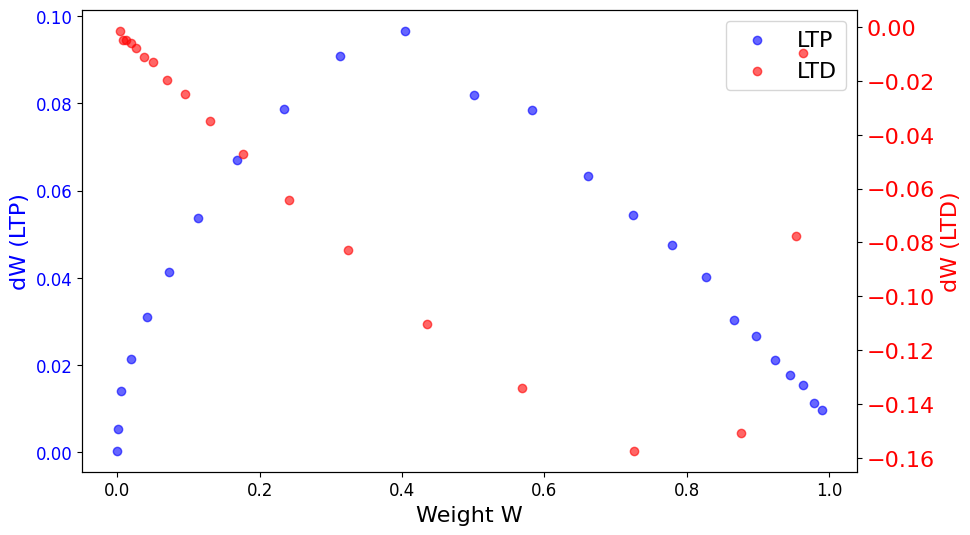

In [22]:
fig, ax1 = plt.subplots(figsize=(10,6))
#Set font size
plt.rcParams.update({'font.size': 16})

ax1.tick_params(axis='both', which='major', labelsize=12)


p1 = ax1.scatter(W_LTP, dW_LTP, color='blue', label='LTP', alpha=0.6)
ax1.set_xlabel('Weight W')
ax1.set_ylabel('dW (LTP)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
p2 = ax2.scatter(W_LTD, dW_LTD, color='red', label='LTD', alpha=0.6)
ax2.set_ylabel('dW (LTD)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.legend([p1, p2], ['LTP', 'LTD'], loc='best')
plt.show()



Mean LTP dW:  0.041666666666666664
Mean LTD dW:  -0.05063916743642747


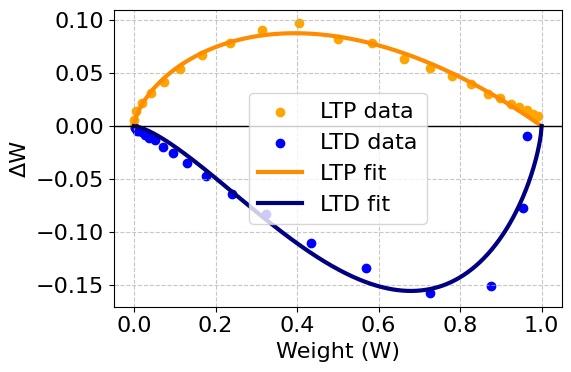

In [24]:
# ---- Mean values ----
mean_LTP = np.mean(dW_LTP)
mean_LTD = np.mean(dW_LTD)
print("Mean LTP dW: ", mean_LTP)
print("Mean LTD dW: ", mean_LTD)

# ---- Beta model ----
def beta_kernel(W, A, alpha, beta):
    return A * (W**(alpha - 1)) * ((1 - W)**(beta - 1))

# Fit LTP
popt_LTP, _ = curve_fit(
    beta_kernel, W_LTP, dW_LTP,
    p0=[0.05, 2, 2],
    bounds=([0,0.1,0.1],[1,10,10])
)

# Fit LTD (magnitude)
popt_LTD, _ = curve_fit(
    beta_kernel, W_LTD, -dW_LTD,
    p0=[0.1, 2, 2],
    bounds=([0,0.1,0.1],[1,10,10])
)

# Generate fitted curves
W_grid = np.linspace(0,1,500)
fit_LTP = beta_kernel(W_grid, *popt_LTP)
fit_LTD = -beta_kernel(W_grid, *popt_LTD)

# ---- Plot ----
plt.figure(figsize=(6,4))
#Set font size
plt.rcParams.update({'font.size': 16})

plt.scatter(W_LTP, dW_LTP, color="orange", label="LTP data")
plt.scatter(W_LTD, dW_LTD, color="blue", label="LTD data")

plt.plot(W_grid, fit_LTP, color="darkorange", linewidth=3, label="LTP fit")
plt.plot(W_grid, fit_LTD, color="navy", linewidth=3, label="LTD fit")

# annotate mean values
# plt.axhline(mean_LTP, color="orange", linestyle="--", linewidth=1.8)
# plt.text(0.02, mean_LTP+0.002, f"mean LTP = {mean_LTP:.4f}", color="orange")

# plt.axhline(mean_LTD, color="blue", linestyle="--", linewidth=1.8)
# plt.text(0.02, mean_LTD-0.004, f"mean LTD = {mean_LTD:.4f}", color="blue")

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Weight (W)")
plt.ylabel("ΔW")
#Add grids
plt.grid(True, linestyle='--', alpha=0.7)


# removed title
# plt.title("")

plt.legend()
plt.tight_layout()
#Save figure
plt.savefig("dW_vs_W_fit.svg", dpi=300)

In [25]:
print ("LTP fit parameters: A = %.4f, alpha = %.4f, beta = %.4f" % tuple(popt_LTP))
print ("LTD fit parameters: A = %.4f, alpha = %.4f, beta = %.4f" % tuple(popt_LTD))



#Fitted parameters from 25mV step size:
# LTP fit parameters: A = 0.1761, alpha = 1.8103, beta = 2.1228
# LTD fit parameters: A = 0.3300, alpha = 2.4721, beta = 1.7929
#Fitted parameters from 50mV step size:
# LTP fit parameters: A = 0.2611, alpha = 1.6429, beta = 1.9873
# LTD fit parameters: A = 0.5969, alpha = 2.4585, beta = 1.6885
# def beta_kernel(W, A, alpha, beta):
    # return A * (W**(alpha - 1)) * ((1 - W)**(beta - 1))
# dW_LTP = beta_kernel(W_mapped, *popt_LTP)
# dW_LTD = -beta_kernel(W_mapped, *popt_LTD)

'''

Let's say that the Wnetwork is in range [-Wmaxnetwork, Wmaxnetwork]

Wmodel = (W_network + Wmaxnetwork) / (2* Wmaxnetwork)

Obtain dWmodel from fitted beta function and Wmodel

dWnetwork =  dWmodel * (2 * Wmaxnetwork)

'''

LTP fit parameters: A = 0.2611, alpha = 1.6429, beta = 1.9873
LTD fit parameters: A = 0.5969, alpha = 2.4585, beta = 1.6885


"\n\nLet's say that the Wnetwork is in range [-Wmaxnetwork, Wmaxnetwork]\n\nWmodel = (W_network + Wmaxnetwork) / (2* Wmaxnetwork)\n\nObtain dWmodel from fitted beta function and Wmodel\n\ndWnetwork =  dWmodel * (2 * Wmaxnetwork)\n\n"

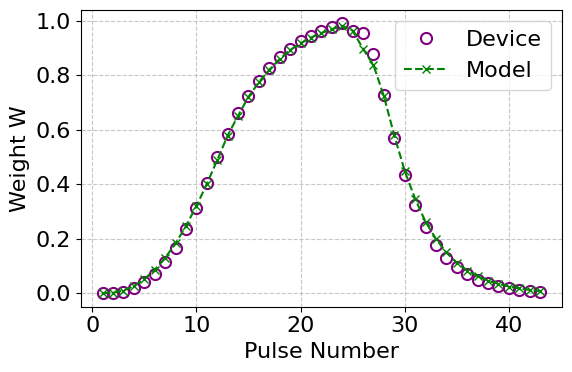

In [26]:
#Plot W as function of pulse number, LTD ammended after LTP
W_array = np.concatenate((W_LTP, W_LTD))
W = pd.Series(W_array)
pulse_numbers = np.arange(1, len(W_array) + 1)
plt.figure(figsize=(6, 4))
#Set font size
plt.rcParams.update({'font.size': 16})
plt.plot(
	pulse_numbers, W,
	marker='o', linestyle='None',
	markerfacecolor='none', markeredgecolor='purple',
	markersize=8, markeredgewidth=1.5,
	label='Device'
)
plt.xlabel('Pulse Number')
plt.ylabel('Weight W')

#Calculate the modelled dW and hence W for the entire pulse sequence. Separate LTP and LTD
dW_modeled_LTP = beta_kernel(W_LTP, *popt_LTP)
dW_modeled_LTD = -beta_kernel(W_LTD, *popt_LTD)

# dW_modeled arrays have same length as W_LTP / W_LTD.
# To compute the "next" weight from the current weight, use the dW corresponding to the next index.
# Use dW_modeled[1:] when adding to W[:-1] so the shapes match.
W_modeled = np.concatenate((
	W_LTP[0:1],
	W_LTP[:-1] + dW_modeled_LTP[1:],
	W_LTD[0:1],
	W_LTD[:-1] + dW_modeled_LTD[1:]
))
plt.plot(pulse_numbers, W_modeled, marker='x', linestyle='--', color='green', label='Model')
#Add grids
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend()
#Save figure
plt.tight_layout()
plt.savefig("W_vs_pulse_model_fit.svg", dpi=300)

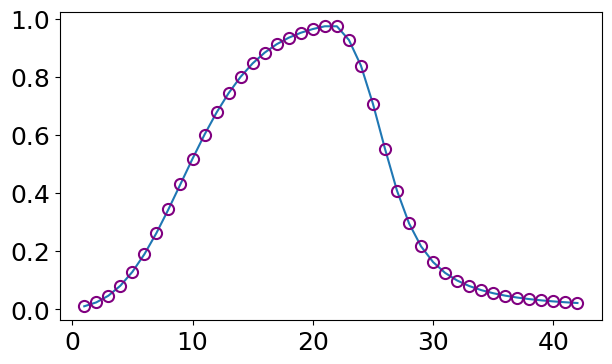

In [39]:
#Start from 0.01 and apply 20 pulses of LTP followed by 20 pulses of LTD
Winit_LTP = 0.01
num_pulses_LTP = 20
num_pulses_LTD = 20

#Plot modelled W vs pulse number from model and initial Winit_LTP

w_array = [Winit_LTP]
for i in range(num_pulses_LTP):
    dW = beta_kernel(w_array[-1], *popt_LTP)
    w_array.append(w_array[-1] + dW)
W_LTP = np.array(w_array)
w_array = [W_LTP[-1]]
for i in range(num_pulses_LTD):
    dW = -beta_kernel(w_array[-1], *popt_LTD)
    w_array.append(w_array[-1] + dW)
W_LTD = np.array(w_array)
W_combined = np.concatenate((W_LTP, W_LTD))


fig = plt.figure(figsize=(7, 4))
#Set font size to 14
plt.rcParams.update({'font.size': 18})
plt.plot(
    np.arange(1, len(W_combined)+1), W_combined,
    marker='o', linestyle='-',
    markerfacecolor='none', markeredgecolor='purple',
    markersize=8, markeredgewidth=1.5,
    label='Modelled W'
)


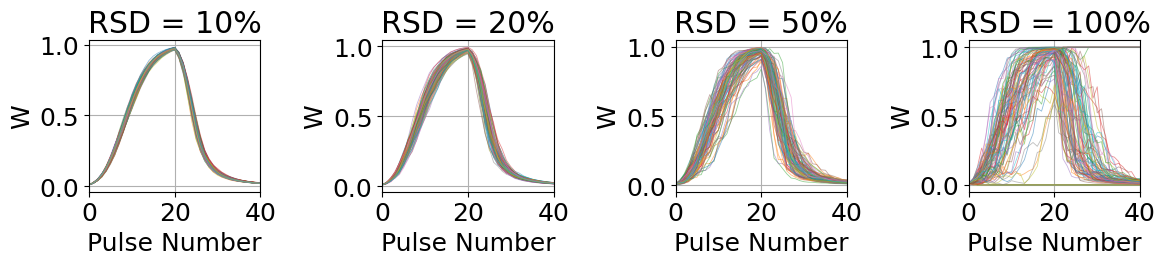

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- User parameters ---
RSD_values = [0.1, 0.2, 0.5, 1.0]
num_samples = 100          # number of repeated noise trials
num_pulses_LTP = 20
num_pulses_LTD = 20

# --- Create subplots ---
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes = axes.flatten()

for idx, (RSD) in enumerate(RSD_values):

    ax = axes[idx]
    ax.set_title(f"RSD = {RSD*100:.0f}%")

    # 100 random trajectories
    for _ in range(num_samples):
        # --- LTP phase ---
        w = [Winit_LTP]  # starting normalized weight
        for i in range(num_pulses_LTP):
            A_noisy = np.random.normal(popt_LTP[0], RSD * popt_LTP[0])
            dW = beta_kernel(w[-1], A_noisy, popt_LTP[1], popt_LTP[2])
            w.append(np.clip(w[-1] + dW, 0, 1))

        # --- LTD phase ---
        for i in range(num_pulses_LTD):
            A_noisy = np.random.normal(popt_LTD[0], RSD * popt_LTD[0])
            dW = -beta_kernel(w[-1], A_noisy, popt_LTD[1], popt_LTD[2])
            w.append(np.clip(w[-1] + dW, 0, 1))

        W_combined = np.array(w)
        ax.plot(W_combined, linewidth=0.6, alpha=0.5)

    ax.set_xlabel("Pulse Number")
    ax.set_ylabel("W")
    ax.grid(True)
    ax.set_xlim(0, num_pulses_LTP + num_pulses_LTD)

plt.tight_layout()
plt.show()



# Not useful from next cell

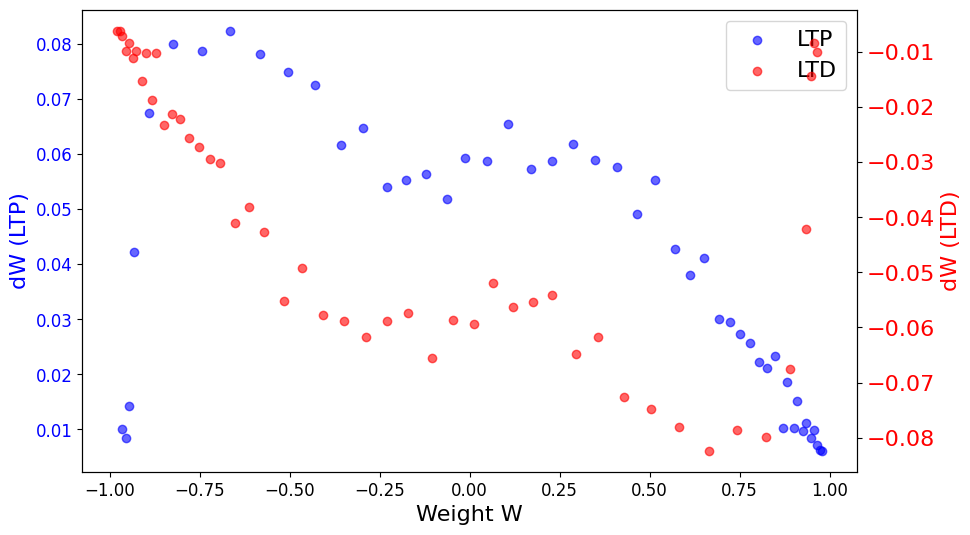

In [57]:
#Repeat for differential dW data
fig, ax1 = plt.subplots(figsize=(10,6))
#Set font size
plt.rcParams.update({'font.size': 16})
ax1.tick_params(axis='both', which='major', labelsize=12)
p1 = ax1.scatter(W_diff_LTP, dW_diff_LTP, color='blue', label='LTP', alpha=0.6)
ax1.set_xlabel('Weight W')
ax1.set_ylabel('dW (LTP)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
p2 = ax2.scatter(W_diff_LTD, dW_diff_LTD, color='red', label='LTD', alpha=0.6)
ax2.set_ylabel('dW (LTD)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax1.legend([p1, p2], ['LTP', 'LTD'], loc='best')
plt.show()

In [59]:
#Print the differential data arrays for reference
print("W_diff_LTP:", W_diff_LTP)
print("dW_diff_LTP:", dW_diff_LTP)
print("W_diff_LTD:", W_diff_LTD)
print("dW_diff_LTD:", dW_diff_LTD)

W_diff_LTP: [-0.965578   -0.95552213 -0.94709927 -0.93274602 -0.89054577 -0.82303395
 -0.74310271 -0.66441771 -0.58203696 -0.50395359 -0.42913623 -0.3565535
 -0.29484315 -0.23003868 -0.17593468 -0.12058444 -0.06424581 -0.01233348
  0.04697035  0.10567254  0.17120756  0.22857757  0.28732273  0.34907606
  0.40795015  0.46562097  0.51478298  0.57004727  0.61272024  0.65083799
  0.69192093  0.72204555  0.75152557  0.7788569   0.80446927  0.82664375
  0.84782982  0.87112162  0.88134938  0.90004297  0.91031371  0.9255694
  0.93536743  0.94654061  0.9549205   0.96480447  0.97198109  0.97825526]
dW_diff_LTP: [0.01005587 0.00842286 0.01435324 0.04220026 0.06751182 0.07993124
 0.078685   0.08238075 0.07808337 0.07481736 0.07258272 0.06171036
 0.06480447 0.054104   0.05535024 0.05633863 0.05191233 0.05930382
 0.05870219 0.06553502 0.05737    0.05874517 0.06175333 0.05887409
 0.05767082 0.04916201 0.05526429 0.04267297 0.03811775 0.04108294
 0.03012462 0.02948002 0.02733133 0.02561238 0.02217447 0